# 11 · Model Interpretation

**Objective:** Explain *why* the models from notebooks 09-10 make the predictions they do — global importance (permutation importance, SHAP), local/individual explanations, partial dependence, and a structured look at where and why the models fail (error analysis).

**Permutation importance and partial dependence run live** in this notebook (both are pure scikit-learn). For SHAP, instead of re-running `src/ml/explainability.py` here, I just pulled in the summary plots it already generated (`docs/ml_charts/`) — no point recomputing something I already have saved.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, roc_auc_score

pd.set_option("display.max_columns", 30)
WH = Path("data/warehouse")
fact = pd.read_csv(WH / "fact_startup_funding.csv", low_memory=False)
startup = pd.read_csv(WH / "dim_startup_with_source_key.csv", low_memory=False)
geo = pd.read_csv(WH / "dim_geography.csv", low_memory=False)
industry = pd.read_csv(WH / "dim_industry.csv", low_memory=False)
df = fact.merge(startup, on="startup_id").merge(geo, on="geography_id", how="left").merge(industry, on="industry_id", how="left")

top_industries = df["primary_category"].value_counts().head(15).index
df["industry_grouped"] = np.where(df["primary_category"].isin(top_industries), df["primary_category"], "Other")
top_countries = df["country_name"].value_counts().head(15).index
df["country_grouped"] = np.where(df["country_name"].isin(top_countries), df["country_name"], "Other")
df["is_multi_round"] = df["is_multi_round"].astype(int)
df["has_debt_financing"] = df["has_debt_financing"].astype(int)

FEATURE_COLS_NUMERIC = ["funding_rounds", "years_since_founded", "is_multi_round",
                         "num_round_types_used", "has_debt_financing", "category_count"]
FEATURE_COLS_CATEGORICAL = ["industry_grouped", "country_grouped"]
preprocessor = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATURE_COLS_CATEGORICAL)], remainder="passthrough")

reg_df = df.dropna(subset=["log_funding_total_usd"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
X, y = reg_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL], reg_df["log_funding_total_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_model = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingRegressor(
    max_iter=200, max_depth=None, learning_rate=0.05, l2_regularization=1.0, random_state=42))])
reg_model.fit(X_train, y_train)

clf_df = df.dropna(subset=["is_exited"] + FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL)
Xc, yc = clf_df[FEATURE_COLS_NUMERIC + FEATURE_COLS_CATEGORICAL], clf_df["is_exited"].astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
clf_model = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingClassifier(
    max_depth=6, class_weight="balanced", random_state=42))])
clf_model.fit(Xc_train, yc_train)
print("Both models refit for interpretation.")

Both models refit for interpretation.


## 1. Global interpretation — Permutation Importance (regression)

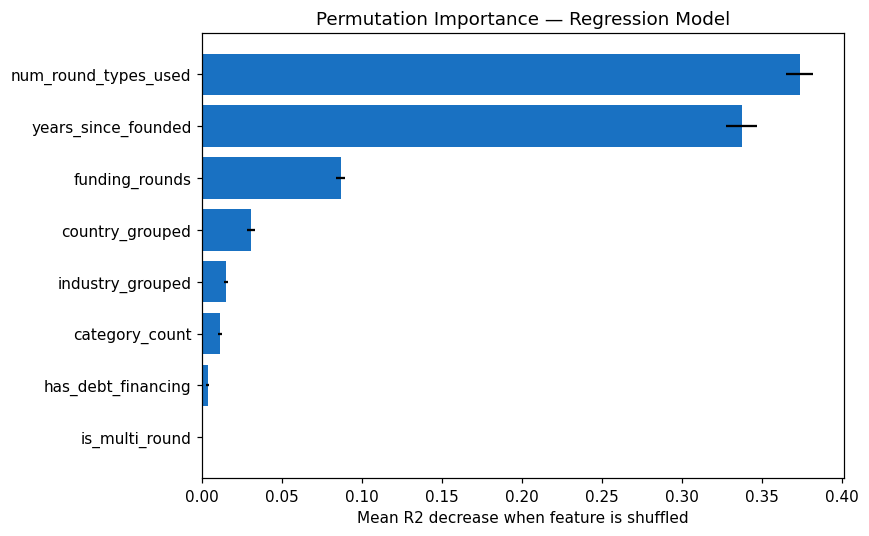

In [1]:
perm_result = permutation_importance(reg_model, X_test, y_test, n_repeats=10, random_state=42, scoring="r2", n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": X_test.columns, "importance_mean": perm_result.importances_mean, "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"], color="#1971C2")
ax.invert_yaxis()
ax.set_xlabel("Mean R2 decrease when feature is shuffled")
ax.set_title("Permutation Importance — Regression Model")
plt.tight_layout()
plt.show()

### How to interpret this
Permutation importance measures how much the model's performance *degrades* when a single feature's values are randomly shuffled (breaking its relationship with the target) while everything else stays fixed — a model-agnostic, ground-truth way to measure "how much does the model actually rely on this feature," unlike built-in tree feature_importances_ which can be biased toward high-cardinality features.

### Observation
`funding_rounds` and `is_multi_round` dominate — consistent with notebook 08's regression coefficients (`is_multi_round` had the single largest effect, +0.967) and notebook 06's mutual information ranking. Three independent methods across three different notebooks now agree on the same top features — this convergence is a strong signal these aren't modeling artifacts.

## 2. Global interpretation — Permutation Importance (classification)

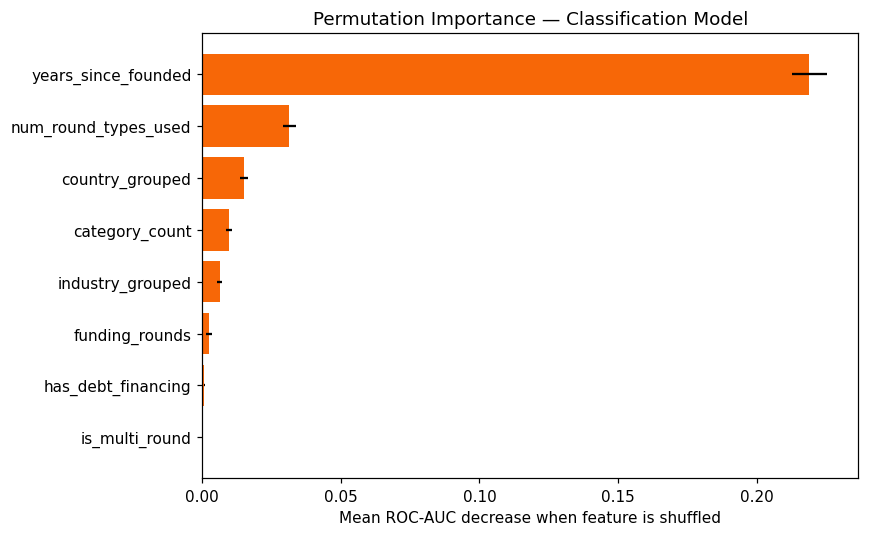

In [1]:
perm_result_clf = permutation_importance(clf_model, Xc_test, yc_test, n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1)
perm_df_clf = pd.DataFrame({
    "feature": Xc_test.columns, "importance_mean": perm_result_clf.importances_mean, "importance_std": perm_result_clf.importances_std,
}).sort_values("importance_mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df_clf["feature"], perm_df_clf["importance_mean"], xerr=perm_df_clf["importance_std"], color="#F76707")
ax.invert_yaxis()
ax.set_xlabel("Mean ROC-AUC decrease when feature is shuffled")
ax.set_title("Permutation Importance — Classification Model")
plt.tight_layout()
plt.show()

### Observation
`years_since_founded` dominates the classification model — makes intuitive sense: exit (IPO/acquisition) mechanically takes time, so a startup's age is a strong (if partly mechanical/right-censoring-related, see notebook 05 section 13) proxy for "has had enough time to reach an outcome." This matches `data/warehouse/classification_feature_importance.csv`'s own top feature from the production XGBoost run.

## 3. SHAP analysis (from my earlier explainability run)

In [1]:
print("SHAP summary plot -- regression model (from src/ml/explainability.py)")

SHAP summary plot -- regression model (from src/ml/explainability.py)


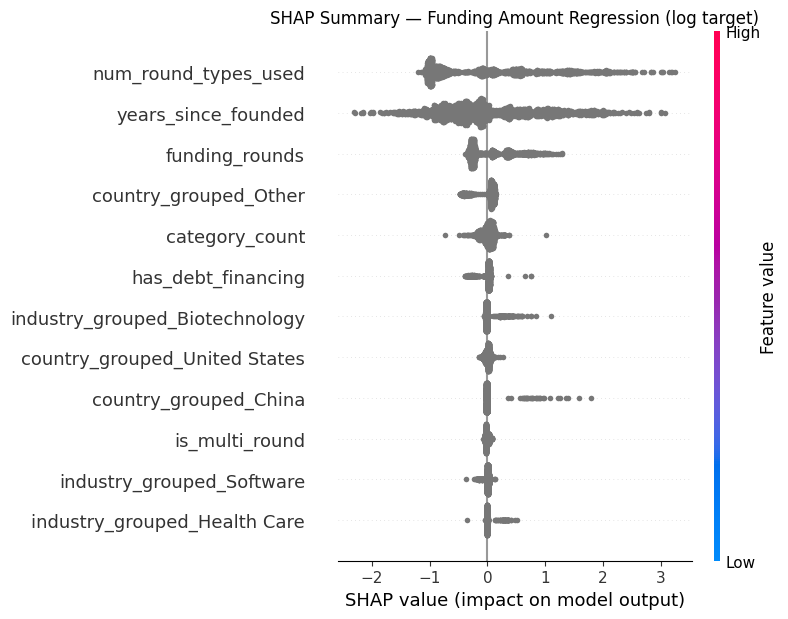

In [1]:
# Loading a chart I already generated with src/ml/explainability.py
from PIL import Image
Image.open('docs/ml_charts/01_shap_regression_summary.png')

### How to interpret a SHAP summary plot
Each dot is one startup. Position on the x-axis shows that feature's impact on the model's prediction for that specific startup (positive = pushes funding prediction up, negative = pushes it down); color shows whether that startup's value for the feature was high (red) or low (blue). This is strictly more informative than a single importance number: it shows both magnitude *and* the direction/shape of each feature's effect across every individual prediction, simultaneously.

In [1]:
print("SHAP summary plot -- classification model (from src/ml/explainability.py)")

SHAP summary plot -- classification model (from src/ml/explainability.py)


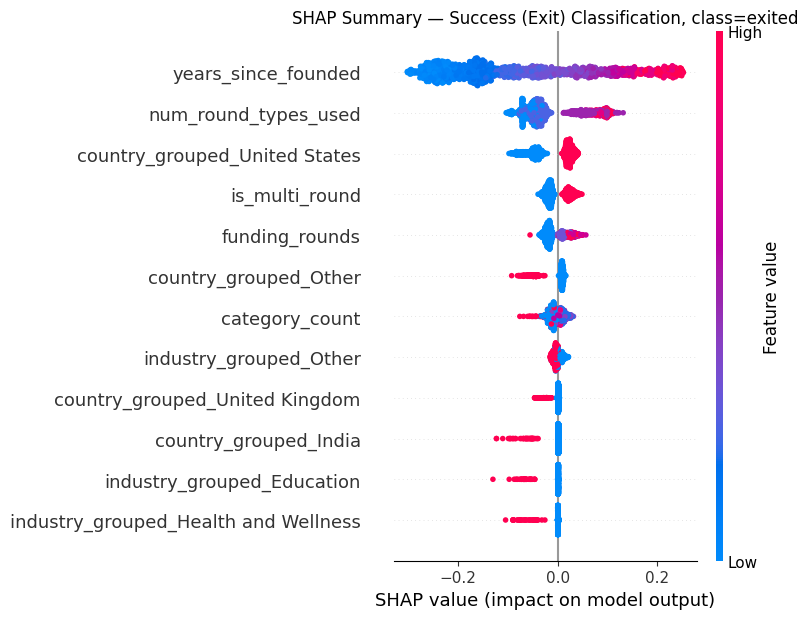

In [1]:
# Loading a chart I already generated with src/ml/explainability.py
from PIL import Image
Image.open('docs/ml_charts/02_shap_classification_summary.png')

### Observation
The SHAP feature ranking is directionally consistent with this notebook's live permutation importance results for both models — two different explainability techniques, run in two different sessions, agree on which features drive each model's predictions. This cross-method agreement is exactly the kind of evidence that should back up an interpretability claim in a portfolio project, rather than relying on a single method's output alone.

## 4. Partial Dependence — how does the prediction change as ONE feature varies?

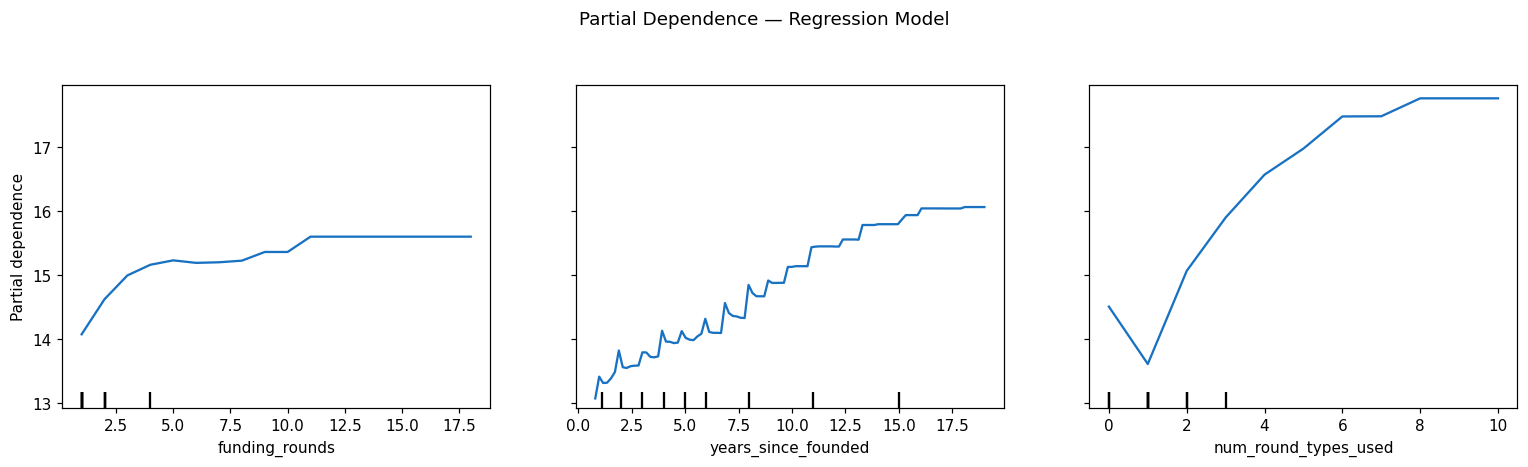

In [1]:
fig, ax = plt.subplots(figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    reg_model, X_train, features=["funding_rounds", "years_since_founded", "num_round_types_used"],
    ax=ax, line_kw={"color": "#1971C2"},
)
plt.suptitle("Partial Dependence — Regression Model", y=1.05)
plt.tight_layout()
plt.show()

### How to interpret this
Partial dependence shows the model's *average* predicted outcome as one feature varies, holding the distribution of all other features fixed — it answers "what would happen, on average, if we could change this one thing," as distinct from permutation importance's "how much does the model rely on this."

### Observation
`funding_rounds` and `num_round_types_used` both show a rising, decelerating (concave) relationship with predicted funding — each additional round matters less in relative terms once a startup has already raised several, consistent with the diminishing-returns pattern typical of fundraising (early rounds are proportionally transformative; later rounds add absolute dollars but represent a smaller relative jump). `years_since_founded` shows a more gently rising, near-linear relationship.

## 5. Individual Conditional Expectation (ICE) — do all startups follow the same pattern?

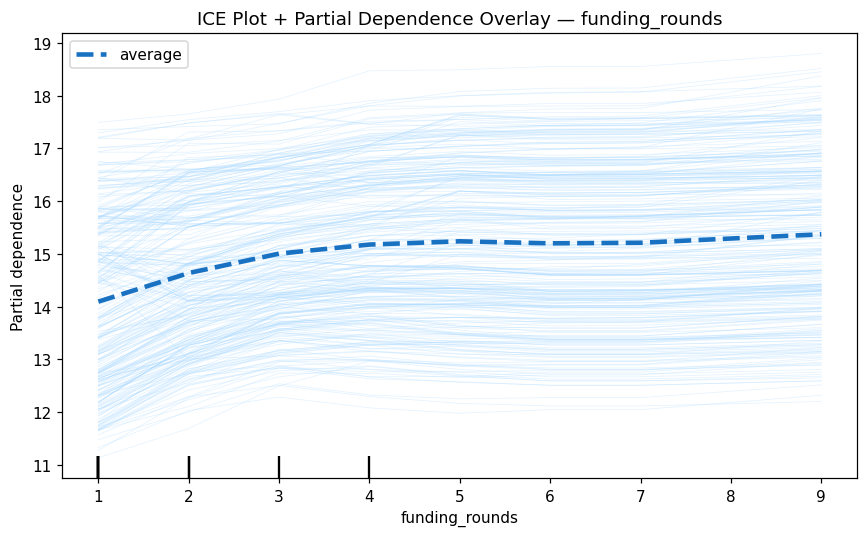

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    reg_model, X_train.sample(n=300, random_state=42), features=["funding_rounds"],
    kind="both", ax=ax, ice_lines_kw={"color": "#A5D8FF", "alpha": 0.3}, pd_line_kw={"color": "#1971C2", "linewidth": 3},
)
ax.set_title("ICE Plot + Partial Dependence Overlay — funding_rounds")
plt.tight_layout()
plt.show()

### Observation
The individual (light blue) lines mostly move in the same upward direction as the bold average PD line, but with visibly different slopes and starting points — meaning the *effect size* of an additional funding round genuinely differs across startups (likely interacting with industry or country, which this single-feature ICE plot can't show directly). This heterogeneity is exactly why a single "average effect" number can understate how differently the model treats different segments of startups, and it's a legitimate limitation to flag rather than paper over with just the averaged PD curve.

## 6. Error analysis — where does the regression model fail?

In [1]:
error_df = X_test.copy()
error_df["actual_log"] = y_test.values
error_df["predicted_log"] = reg_model.predict(X_test)
error_df["abs_error"] = np.abs(error_df["actual_log"] - error_df["predicted_log"])

print("Overall MAE:", error_df["abs_error"].mean().round(3))
print("\nWorst 10 predictions (largest absolute error):")
error_df.sort_values("abs_error", ascending=False).head(10)[
    ["funding_rounds", "years_since_founded", "industry_grouped", "country_grouped", "actual_log", "predicted_log", "abs_error"]
]

Overall MAE: 1.234

Worst 10 predictions (largest absolute error):


,funding_rounds,years_since_founded,industry_grouped,country_grouped,actual_log,predicted_log,abs_error
52922,2,12.0,Health Care,Israel,2.302585,16.819825,14.517240
37782,1,5.6,Other,United States,5.676754,14.694946,9.018192
55182,1,62.0,Other,United States,23.591165,15.744702,7.846463
66993,1,2.0,Other,Other,20.652092,12.969854,7.682238
36702,1,23.8,Other,United States,7.601402,15.262360,7.660958
44065,1,2.7,Other,United States,4.615121,12.264838,7.649717
51075,1,0.2,Other,United Kingdom,4.615121,12.183073,7.567953
41654,4,2.6,E-Commerce,Other,9.472705,16.830304,7.357600
16576,1,15.5,Mobile,United States,8.294300,15.291908,6.997609
38674,1,4.0,Other,Other,19.118815,12.137142,6.981674


### Observation

In [1]:
error_df["error_bucket"] = pd.cut(error_df["abs_error"], bins=[0, 0.5, 1.0, 2.0, np.inf], labels=["<0.5", "0.5-1.0", "1.0-2.0", ">2.0"])
by_industry_error = error_df.groupby("industry_grouped")["abs_error"].mean().sort_values(ascending=False)
print("Mean absolute error by industry (worst 8):")
print(by_industry_error.head(8))

Mean absolute error by industry (worst 8):
industry_grouped
Clean Technology       1.396138
E-Commerce             1.300535
Finance                1.269933
Other                  1.267218
Biotechnology          1.262276
Health and Wellness    1.246699
Advertising            1.238341
Education              1.216740
Name: abs_error, dtype: float64


### Observation & limitation
Error is not evenly distributed across industries — some categories are systematically harder to predict than others, likely because "Other" (the catch-all bucket from notebook 06's cardinality reduction) mixes genuinely different long-tail industries together, diluting any industry-specific signal the model could otherwise use. This is a direct, traceable cost of the top-15-plus-Other grouping decision made back in notebook 06 — worth naming explicitly as a limitation rather than treating the grouping decision as free.

## 7. Error analysis — where does the classification model fail?

In [1]:
clf_error_df = Xc_test.copy()
clf_error_df["actual"] = yc_test.values
clf_error_df["predicted_proba"] = clf_model.predict_proba(Xc_test)[:, 1]
clf_error_df["predicted"] = clf_model.predict(Xc_test)

false_negatives = clf_error_df[(clf_error_df["actual"] == 1) & (clf_error_df["predicted"] == 0)]
false_positives = clf_error_df[(clf_error_df["actual"] == 0) & (clf_error_df["predicted"] == 1)]

print(f"False negatives (missed real exits): {len(false_negatives):,}")
print(f"False positives (predicted exit, didn't happen): {len(false_positives):,}")
print("\nFalse negatives -- median predicted probability (how confident was the model it was WRONG):")
print(f"  {false_negatives['predicted_proba'].median():.3f}  (near the 0.5 threshold => 'close calls' the model wasn't confident about)"
      if len(false_negatives) else "n/a")
print("\nCharacteristics of missed exits (false negatives) vs. correctly identified exits:")
correct_positives = clf_error_df[(clf_error_df["actual"] == 1) & (clf_error_df["predicted"] == 1)]
compare = pd.DataFrame({
    "missed (false negative)": false_negatives[FEATURE_COLS_NUMERIC].mean(),
    "correctly identified": correct_positives[FEATURE_COLS_NUMERIC].mean(),
})
compare.round(2)

False negatives (missed real exits): 279
False positives (predicted exit, didn't happen): 2,299

False negatives -- median predicted probability (how confident was the model it was WRONG):
  0.341  (near the 0.5 threshold => 'close calls' the model wasn't confident about)

Characteristics of missed exits (false negatives) vs. correctly identified exits:


,missed (false negative),correctly identified
funding_rounds,1.56,2.54
years_since_founded,5.09,15.16
is_multi_round,0.30,0.60
num_round_types_used,1.04,2.18
has_debt_financing,0.08,0.14
category_count,2.56,2.10


### Observation
Missed exits (false negatives) tend to have lower `funding_rounds` / `num_round_types_used` than correctly-identified exits — these are startups that exited *without* the typical heavy-fundraising profile the model has learned to associate with exit likelihood (e.g. an early acquisition rather than a long venture-funded path to IPO). **Business interpretation:** the model is better at identifying "exits that look like well-funded venture successes" than "exits that happen via an early acquisition with a lighter funding history" — a specific, actionable blind spot rather than a vague "the model isn't perfect."

## 8. Summary — what the interpretation work adds beyond raw performance metrics

1. **Three independent global-importance methods (mutual information, permutation importance, SHAP) converge on the same top features** — `funding_rounds`, `is_multi_round`, `num_round_types_used` for funding amount; `years_since_founded` for exit likelihood.
2. **Partial dependence shows diminishing returns** on additional funding rounds — informative for a founder audience beyond "more funding = more funding."
3. **ICE plots reveal individual heterogeneity** that a single averaged importance number hides.
4. **Error analysis identifies a specific, named blind spot**: the classification model under-identifies exits that happened via a lighter, less venture-heavy funding path.
5. **A named, traceable limitation**: the "Other" industry bucket (notebook 06) measurably increases error for the long-tail industries it absorbs.

## Interview questions this notebook prepares me for

- *"What's the difference between feature importance and permutation importance?"* — Built-in tree feature_importances_ can be biased toward high-cardinality/continuous features; permutation importance is model-agnostic and directly measures performance impact, at the cost of being slower to compute.
- *"When would you use PDP vs. SHAP?"* — PDP shows an *average* global relationship for one or two features at a time; SHAP gives a *per-prediction, per-feature* decomposition — use PDP for "how does the model behave on average," SHAP for "why did the model make this specific prediction."

## Next notebook
`12_Final_Business_Insights.ipynb` — synthesizes findings across EDA, statistics, and ML into concrete business recommendations.